<a href="https://colab.research.google.com/github/naabiiill/Machine_Learning/blob/main/Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"
df = pd.read_csv(url)

# Display first 5 rows
print("First 5 rows:")
display(df.head())

# Check data types and information
print("\nDataset Information:")
df.info()

# Descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Descriptive Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Calculate percentage of missing values in Cabin
cabin_missing = df["Cabin"].isnull().mean() * 100

print(f"Percentage of missing Cabin values: {cabin_missing:.2f}%")

# Drop Cabin because it has a very high percentage of missing values
df = df.drop("Cabin", axis=1)

print("\nCabin column dropped because it contains a large amount of missing data.")

# Find the most frequent Embarked value
embarked_mode = df["Embarked"].mode()[0]

print(f"Most frequent Embarked port: {embarked_mode}")

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

# Find median Age
age_median = df["Age"].median()

print(f"Median Age: {age_median}")

# Fill missing Age values with median
df["Age"] = df["Age"].fillna(age_median)

# Check missing values after handling
print("\nMissing values after handling:")
print(df.isnull().sum())

Percentage of missing Cabin values: 77.10%

Cabin column dropped because it contains a large amount of missing data.
Most frequent Embarked port: S
Median Age: 28.0

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Overall Survival Rate: 38.38%


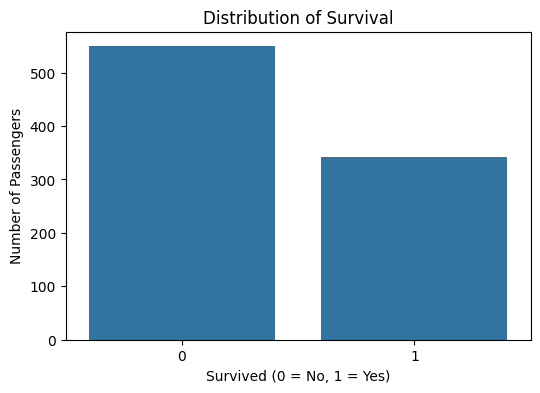

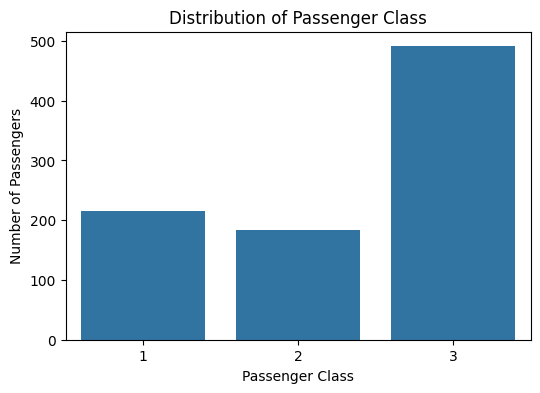

Number of passengers in each class:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Class with the most passengers: 3


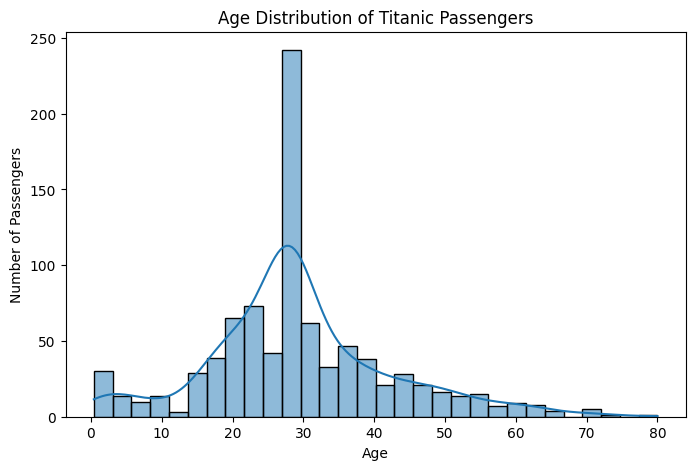

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Overall survival rate
survival_rate = df["Survived"].mean() * 100

print(f"Overall Survival Rate: {survival_rate:.2f}%")

# Survival distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Survived")
plt.title("Distribution of Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()


# Passenger Class distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Pclass")
plt.title("Distribution of Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

print("Number of passengers in each class:")
print(df["Pclass"].value_counts())

print("Class with the most passengers:", df["Pclass"].value_counts().idxmax())


# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

Survival Count by Sex:


Survived,0,1
Sex,,
female,81,233
male,468,109


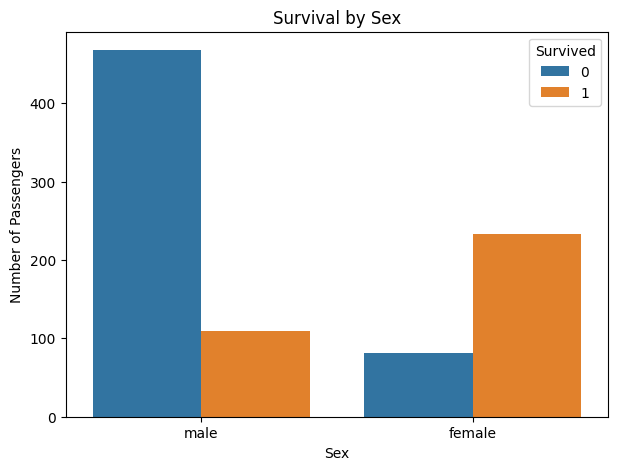

Survival Rate by Sex:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Survival Rate by Passenger Class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


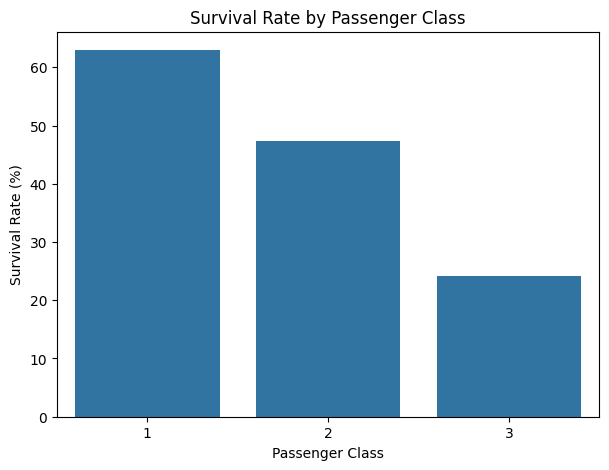

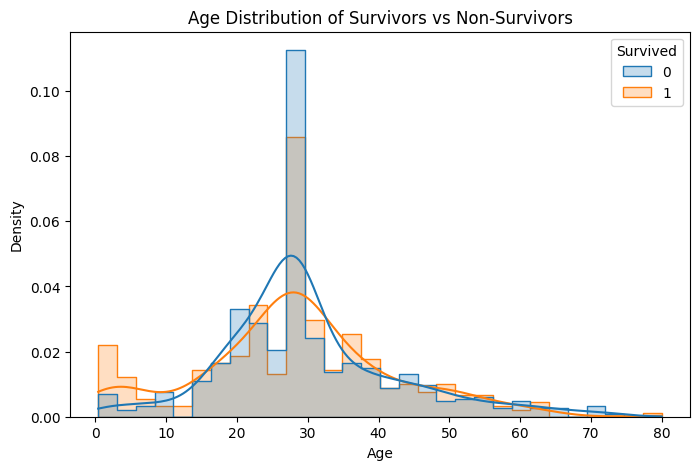


Survival Rate by Embarked Port:
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


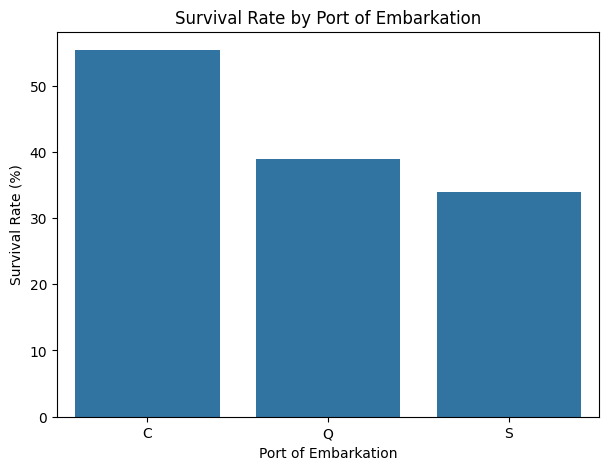

In [ ]:
# --------------------------------
# Survival by Sex
# --------------------------------

sex_survival = pd.crosstab(df["Sex"], df["Survived"])

print("Survival Count by Sex:")
display(sex_survival)

# Visualization
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Passengers")
plt.show()

# Survival rate by sex
sex_survival_rate = df.groupby("Sex")["Survived"].mean() * 100

print("Survival Rate by Sex:")
print(sex_survival_rate)


# --------------------------------
# Survival by Passenger Class
# --------------------------------

class_survival_rate = df.groupby("Pclass")["Survived"].mean() * 100

print("\nSurvival Rate by Passenger Class:")
print(class_survival_rate)

plt.figure(figsize=(7,5))
sns.barplot(x=class_survival_rate.index, y=class_survival_rate.values)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.show()


# --------------------------------
# Survival by Age
# --------------------------------

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Age Distribution of Survivors vs Non-Survivors")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()


# --------------------------------
# Survival by Embarked Port
# --------------------------------

embarked_survival_rate = df.groupby("Embarked")["Survived"].mean() * 100

print("\nSurvival Rate by Embarked Port:")
print(embarked_survival_rate)

plt.figure(figsize=(7,5))
sns.barplot(
    x=embarked_survival_rate.index,
    y=embarked_survival_rate.values
)

plt.title("Survival Rate by Port of Embarkation")
plt.xlabel("Port of Embarkation")
plt.ylabel("Survival Rate (%)")
plt.show()

In [ ]:
print("""
Conclusion:

The EDA shows that Sex, Passenger Class, and Age were important factors
affecting survival on the Titanic. Female passengers had a significantly
higher survival rate than male passengers. Passengers in 1st class had a
higher survival probability than passengers in 2nd and 3rd class. The age
distribution also suggests that children had relatively better survival
chances than many older passengers.
""")


Conclusion:

The EDA shows that Sex, Passenger Class, and Age were important factors
affecting survival on the Titanic. Female passengers had a significantly
higher survival rate than male passengers. Passengers in 1st class had a
higher survival probability than passengers in 2nd and 3rd class. The age
distribution also suggests that children had relatively better survival
chances than many older passengers.

